In [7]:
import requests
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import logging
from collections import defaultdict
from conjugate_normal import conjugate_normal

# Set up logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

In [ ]:
API_KEY = ""
CLASS_ID = "Tobasum-Testing-Joyner-Data"
SAMPLE_SIZE = 10  # Set to a number for testing or None for all data

In [9]:
def get_score_history(user_id, current_timestamp, df_sorted):
    """Get actual score history for this user up to this point"""
    # Check if DataFrame has required columns
    if df_sorted.empty or 'user_id' not in df_sorted.columns or 'created_at' not in df_sorted.columns:
        return []  # Return empty for invalid/empty dataframes
    
    # Get all previous submissions for this user before current timestamp
    user_previous = df_sorted[
        (df_sorted['user_id'] == user_id) & 
        (df_sorted['created_at'] < current_timestamp)
    ]
    
    # Return their content scores as the score history
    if len(user_previous) > 0 and 'content_score' in user_previous.columns:
        return user_previous['content_score'].tolist()
    else:
        return []  # First submission for this user or missing content_score column

def call_summary_api(summary_text, user_id, timestamp, df_sorted, page_slug, class_id="Tobasum-Testing-Joyner-Data"):
    url = "https://itell-api.learlab.vanderbilt.edu/score/summary"

    try:
        # Get actual score history for this user
        score_history = get_score_history(user_id, timestamp, df_sorted)
        logger.info(f"Processing user {user_id}, page {page_slug}, score history length: {len(score_history)}")

        payload = {
            "page_slug": page_slug,
            "class_id": class_id,
            "score_history": score_history,
            "summary": summary_text
        }
        headers = {
            "Content-Type": "application/json",
            "API-Key": API_KEY
        }

        response = requests.request("POST", url, json=payload, headers=headers, timeout=30)
        
        # Check if request was successful
        if response.status_code == 200:
            response_dict = response.json()
            # Add metadata to the response for tracking
            response_dict['api_metadata'] = {
                'user_id': user_id,
                'timestamp': timestamp.isoformat() if hasattr(timestamp, 'isoformat') else str(timestamp),
                'page_slug': page_slug,
                'score_history': score_history,
                'status_code': response.status_code,
                'request_payload': payload
            }
            logger.info(f"Successfully processed API call for user {user_id}")
            return response_dict
        else:
            # Provide error messages based on status code
            error_msg = f"API call failed for user {user_id}. Status code: {response.status_code}"
            if response.status_code == 404:
                error_msg += f" - Class '{class_id}' might not exist"
            elif response.status_code == 401:
                error_msg += " - Authentication failed (check API key)"
            elif response.status_code == 400:
                error_msg += " - Bad request (check payload format)"
            
            logger.error(f"{error_msg}, Response: {response.text}")
            return {
                'error': True,
                'status_code': response.status_code,
                'response_text': response.text,
                'error_suggestion': f"Status {response.status_code}: {'Class not found' if response.status_code == 404 else 'Check API key' if response.status_code == 401 else 'Check request format'}",
                'api_metadata': {
                    'user_id': user_id,
                    'timestamp': timestamp.isoformat() if hasattr(timestamp, 'isoformat') else str(timestamp),
                    'page_slug': page_slug,
                    'score_history': score_history,
                    'request_payload': payload
                }
            }
            
    except requests.exceptions.Timeout:
        logger.error(f"Timeout error for user {user_id}")
        return {
            'error': True,
            'error_type': 'timeout',
            'api_metadata': {
                'user_id': user_id,
                'timestamp': timestamp.isoformat() if hasattr(timestamp, 'isoformat') else str(timestamp),
                'page_slug': page_slug
            }
        }
    except requests.exceptions.RequestException as e:
        logger.error(f"Request error for user {user_id}: {str(e)}")
        return {
            'error': True,
            'error_type': 'request_exception',
            'error_message': str(e),
            'api_metadata': {
                'user_id': user_id,
                'timestamp': timestamp.isoformat() if hasattr(timestamp, 'isoformat') else str(timestamp),
                'page_slug': page_slug
            }
        }
    except Exception as e:
        logger.error(f"Unexpected error for user {user_id}: {str(e)}")
        return {
            'error': True,
            'error_type': 'unexpected',
            'error_message': str(e),
            'api_metadata': {
                'user_id': user_id,
                'timestamp': timestamp.isoformat() if hasattr(timestamp, 'isoformat') else str(timestamp),
                'page_slug': page_slug
            }
        }

In [11]:
# Load the data from server
df = pd.read_csv("summaries.csv")

# Display basic info about the data
print(f"Total rows: {len(df)}")
print(f"Columns: {list(df.columns)}")
print(f"Unique users: {df['user_id'].nunique()}")
print(f"Date range: {df['created_at'].min()} to {df['created_at'].max()}")

# Show sample data
display(df.head())

# Prepare data for API calls
required_cols = ['user_id', 'text', 'created_at'] 
missing_cols = [col for col in required_cols if col not in df.columns]

if missing_cols:
    print(f"Missing columns: {missing_cols}")
    print("Available columns: {list(df.columns)}")
else:
    print("All required columns present")
    
# Sort by timestamp
df['created_at'] = pd.to_datetime(df['created_at'])
df = df.sort_values('created_at')
print(f"Rows after sorting: {len(df)}")

Total rows: 994
Columns: ['id', 'text', 'condition', 'user_id', 'page_slug', 'is_passed', 'containment_score', 'similarity_score', 'content_score', 'content_threshold', 'is_excellent', 'created_at', 'updated_at']
Unique users: 127
Date range: 2025-06-02T15:40:05.637001+00:00 to 2025-07-21T19:10:20.558299+00:00


,id,text,condition,user_id,page_slug,is_passed,containment_score,similarity_score,content_score,content_threshold,is_excellent,created_at,updated_at
0,60,Thi spage talks about how contril stuctues are...,random_reread,226ajlpobyjbksx534h6rrg2jq,3-1-control-structures,True,0.0000,0.736030,0.170597,0.004953,True,2025-06-02T15:40:05.637001+00:00,2025-06-02T15:40:05.637001+00:00
1,61,"In this chapter of the unit 3 lessons, the art...",random_reread,226ajlpobyjbksx534h6rrg2jq,3-2-conditionals,True,0.0000,0.520184,0.077714,0.004953,True,2025-06-02T17:31:34.022806+00:00,2025-06-02T17:31:34.022806+00:00
2,62,"In this section of the lesson for unit 3, the ...",random_reread,226ajlpobyjbksx534h6rrg2jq,3-3-loops,True,0.0000,0.779228,0.349814,0.004953,True,2025-06-02T17:36:51.540634+00:00,2025-06-02T17:36:51.540634+00:00
3,63,"In this chapter of unit 3, the article talks a...",random_reread,226ajlpobyjbksx534h6rrg2jq,3-4-functions,True,0.0000,0.758652,0.611322,0.004953,True,2025-06-02T17:41:39.63132+00:00,2025-06-02T17:41:39.63132+00:00
4,64,"In this article for unit 3, the article talks ...",random_reread,226ajlpobyjbksx534h6rrg2jq,3-5-error-handling,True,0.1053,0.785503,0.431579,0.004953,True,2025-06-02T17:50:59.201884+00:00,2025-06-02T17:50:59.201884+00:00


All required columns present
Rows after sorting: 994


In [ ]:
# Test API connection and class availability

def test_api_connection():
    """Test API connection with a simple request"""
    try:
        test_response = call_summary_api(
            summary_text="This is a test summary to check API connectivity.",
            user_id="test_user_123",
            timestamp=pd.Timestamp.now(),
            df_sorted=pd.DataFrame(),  # Empty df for test
            page_slug="test-page",
            class_id=CLASS_ID
        )
        
        if test_response.get('error'):
            error_msg = (test_response.get('error_suggestion') or 
                        test_response.get('error_message') or 
                        test_response.get('error_type') or 
                        'Unknown error')
            print(f"API Test Failed: {error_msg}")
            
            if test_response.get('status_code') == 404:
                print(f"Create class '{CLASS_ID}' or use an existing class")
            elif test_response.get('status_code') == 401:
                print("Check your API_KEY variable")
            return False
        else:
            print("API Test Successful!")
            print(f"Class: {CLASS_ID}")
            print(f"Response contains: {list(test_response.keys())}")
            return True
            
    except Exception as e:
        print(f"API Test Error: {str(e)}")
        return False

test_api_connection()

2025-08-27 15:08:10,606 - INFO - Processing user test_user_123, page test-page, score history length: 0


2025-08-27 15:08:13,457 - INFO - Successfully processed API call for user test_user_123


API Test Successful!
Class: Tobasum-Testing-Joyner-Data
Response contains: ['is_passed', 'prompt', 'metrics', 'api_metadata']


True

In [13]:
# Sample data if needed
if SAMPLE_SIZE is not None:
    df = df.sample(n=min(SAMPLE_SIZE, len(df)), random_state=42)
    print(f"Testing with {len(df)} sampled entries")
else:
    print(f"Testing with all {len(df)} entries")

Testing with 10 sampled entries


In [ ]:
print("Making API calls...")
logger.info(f"Starting API calls for {len(df)} submissions")

all_responses = []

for i, row in enumerate(df.itertuples()):
    print(f"Processing summary {i+1}/{len(df)} for user {row.user_id}")
    
    summary_text = row.text
    user_id = row.user_id
    timestamp = row.created_at
    
    # Call API with actual score history for this user
    response = call_summary_api(summary_text, user_id, timestamp, df, row.page_slug, CLASS_ID)
    
    if response:
        all_responses.append(response)
    
    # Small delay
    import time
    time.sleep(0.1)

print(f"Completed {len(all_responses)} API calls")

# Save to JSONL file
output_filename = "summary_scores.jsonl"
with open(output_filename, "w") as f:
    for response in all_responses:
        f.write(json.dumps(response) + "\n")

print(f"Saved API responses to {output_filename}")
logger.info(f"Saved {len(all_responses)} responses to {output_filename}")

2025-08-27 15:10:00,925 - INFO - Starting API calls for 10 submissions
2025-08-27 15:10:00,961 - INFO - Processing user qkurz4fxzcfq2mxdgchs3gl5zi, page 4-4-file-input-and-output, score history length: 0


Making API calls...
Processing summary 1/10 for user qkurz4fxzcfq2mxdgchs3gl5zi


2025-08-27 15:10:04,603 - INFO - Successfully processed API call for user qkurz4fxzcfq2mxdgchs3gl5zi
2025-08-27 15:10:04,716 - INFO - Processing user d7y2g5m7ke4cq5e4ouyou7apu4, page 3-3-loops, score history length: 0


Processing summary 2/10 for user d7y2g5m7ke4cq5e4ouyou7apu4


2025-08-27 15:10:07,884 - INFO - Successfully processed API call for user d7y2g5m7ke4cq5e4ouyou7apu4
2025-08-27 15:10:07,989 - INFO - Processing user 676q6x5mvr3ha2hgb2yu6kyv7i, page 3-2-conditionals, score history length: 0


...

Processing summary 9/10 for user istajre3ni5tbfwekveddzftni


2025-08-27 15:10:29,406 - INFO - Successfully processed API call for user istajre3ni5tbfwekveddzftni
2025-08-27 15:10:29,514 - INFO - Processing user dlnvl73qpsd72fy4huqnm2leda, page 4-4-file-input-and-output, score history length: 0


Processing summary 10/10 for user dlnvl73qpsd72fy4huqnm2leda


2025-08-27 15:10:31,016 - INFO - Successfully processed API call for user dlnvl73qpsd72fy4huqnm2leda
2025-08-27 15:10:31,123 - INFO - Saved 10 responses to real_summary_scores_complete.jsonl


Completed 10 API calls
Saved API responses to real_summary_scores_complete.jsonl


In [ ]:
# Load and process API responses

print("Loading API responses...")

try:
    # Load responses
    with open("summary_scores.jsonl", "r") as f:
        responses = [json.loads(line) for line in f]
    
    print(f"Loaded {len(responses)} responses")
    
    # Filter successful responses
    successful_responses = [r for r in responses if not r.get('error', False)]
    print(f"Found {len(successful_responses)} successful responses")
    
    # Process successful responses for analysis
    if len(successful_responses) > 0:
        # Extract metrics from the responses
        metrics_list = []
        for response in successful_responses:
            if 'metrics' in response:
                metric_data = response['metrics'].copy()
                # Add metadata for tracking
                if 'api_metadata' in response:
                    metric_data.update({
                        'user_id': response['api_metadata']['user_id'],
                        'timestamp': response['api_metadata']['timestamp'],
                        'page_slug': response['api_metadata']['page_slug'],
                        'score_history_length': len(response['api_metadata'].get('score_history', []))
                    })
                metrics_list.append(metric_data)
        
        if metrics_list:
            global df_metrics
            df_metrics = pd.DataFrame(metrics_list)
            print(f"Processed {len(df_metrics)} responses with metrics")
            display(df_metrics.sample(min(3, len(df_metrics))))
        else:
            print("No metrics found in responses")
    else:
        print("No successful responses to analyze")
            
except FileNotFoundError:
    print("Error: real_summary_scores_complete.jsonl not found. Please run the API calls first.")
except Exception as e:
    print(f"Error loading responses: {str(e)}")


Loading API responses...
Loaded 10 responses
Found 10 successful responses
Processed 10 responses with metrics


,containment,containment_chat,content,similarity,english,profanity,user_id,timestamp,page_slug,score_history_length
2,"{'name': 'Language Borrowing', 'is_passed': Tr...","{'name': 'Language Borrowing (from iTELL AI)',...","{'name': 'Content', 'is_passed': True, 'score'...","{'name': 'Relevance', 'is_passed': True, 'scor...","{'name': 'English', 'is_passed': True, 'score'...","{'name': 'Profanity', 'is_passed': True, 'scor...",676q6x5mvr3ha2hgb2yu6kyv7i,2025-06-29T15:23:38.855586+00:00,3-2-conditionals,0
5,"{'name': 'Language Borrowing', 'is_passed': Tr...","{'name': 'Language Borrowing (from iTELL AI)',...","{'name': 'Content', 'is_passed': True, 'score'...","{'name': 'Relevance', 'is_passed': True, 'scor...","{'name': 'English', 'is_passed': True, 'score'...","{'name': 'Profanity', 'is_passed': True, 'scor...",avhaidfrpkwpcgza4tvilzj23i,2025-06-20T02:33:55.729368+00:00,3-1-control-structures,0
9,"{'name': 'Language Borrowing', 'is_passed': Tr...","{'name': 'Language Borrowing (from iTELL AI)',...","{'name': 'Content', 'is_passed': True, 'score'...","{'name': 'Relevance', 'is_passed': True, 'scor...","{'name': 'English', 'is_passed': True, 'score'...","{'name': 'Profanity', 'is_passed': True, 'scor...",dlnvl73qpsd72fy4huqnm2leda,2025-07-06T01:14:38.066843+00:00,4-4-file-input-and-output,0


Total submissions: 10
Mean content score: 0.363
Submissions with score history: 0


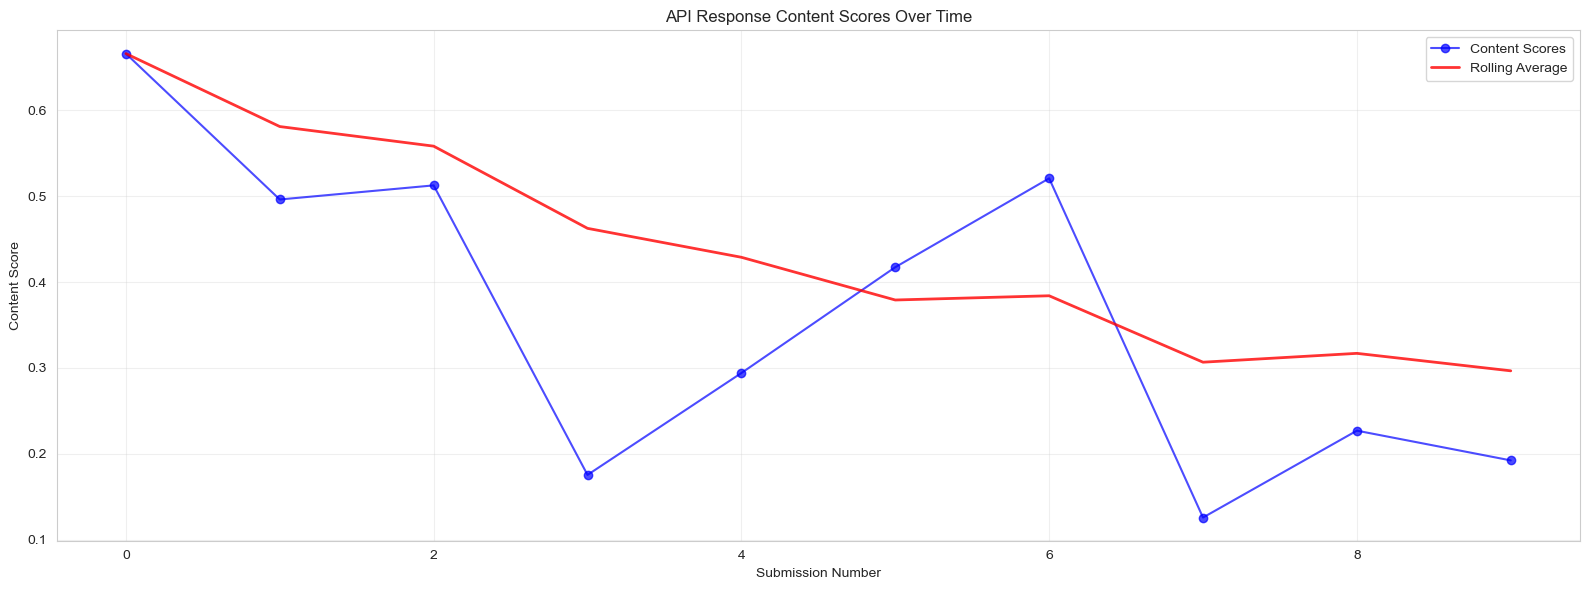

In [ ]:
# Visualization
if 'df_metrics' in globals() and len(df_metrics) > 0:
    # Extract content scores from the API response data
    content_scores = []
    timestamps = []
    
    for idx, row in df_metrics.iterrows():
        if 'content' in row and isinstance(row['content'], dict):
            content_scores.append(row['content'].get('score', 0))
            timestamps.append(row['timestamp'])
    
    # Convert to pandas series for plotting
    content_scores = pd.Series(content_scores)
    timestamps = pd.to_datetime(timestamps)
    
    sns.set_style("whitegrid")
    fig, ax = plt.subplots(1, figsize=(16, 6))
    
    # Plot content scores over time
    ax.plot(range(len(content_scores)), content_scores, 'o-', color='blue', alpha=0.7, label='Content Scores')
    
    # Add rolling average
    rolling_avg = content_scores.rolling(window=min(5, len(content_scores)), min_periods=1).mean()
    ax.plot(range(len(rolling_avg)), rolling_avg, '-', color='red', linewidth=2, alpha=0.8, label='Rolling Average')
    
    # Format the plot
    plt.title('API Response Content Scores Over Time')
    plt.xlabel('Submission Number')
    plt.ylabel('Content Score')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    
    # Print basic statistics
    print(f"Total submissions: {len(content_scores)}")
    print(f"Mean content score: {content_scores.mean():.3f}")
    print(f"Submissions with score history: {df_metrics['score_history_length'].sum()}")
    
    plt.show()
else:
    print("No metrics data available for visualization. Please run the API calls first.")
